# Stage 20 — M4-attn Training

Trains `ProtoSegNet(proto_levels=[1,2,3,4], use_level_attention=True)`.

**Primary experiment for RQ4/RQ5:** same level set as M4, only the aggregation changes
(learned weighted sum vs winner-takes-all max). Compares against:
- **M4** (L1–L4, max): 3D Dice 0.8407
- **M2** (L3–L4, max): 3D Dice 0.8722  ← ceiling

Attention weights are frozen in Phase A (uniform 0.25), learned from Phase B onward.

## 0. Config

In [1]:
import sys, os
_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault('PYTORCH_MPS_HIGH_WATERMARK_RATIO', '0.0')
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

# ── Attention config ──────────────────────────────────────────────────────────
PROTO_LEVELS        = [1, 2, 3, 4]   # full multi-scale — same as M4
USE_LEVEL_ATTENTION = True
MODALITY            = 'ct'
SUFFIX              = '_l1234_attn_noent'

# ── Hyperparameters (same as v1 / M2) ────────────────────────────────────────
LAMBDA_ENT         = 0.0    # entropy regularisation weight (prevents attn collapse)
ATTN_WARMUP_EPOCHS = 10     # epochs into Phase B before attention is unfrozen
LAMBDA_DIV    = 0.001
LAMBDA_PUSH   = 0.5
LAMBDA_PULL   = 0.25
BATCH_SIZE    = 16
LR            = 3e-4
WEIGHT_DECAY  = 1e-5
PHASE_A_END   = 20
PHASE_B_END   = 80
PHASE_C_END   = 100
VAL_EVERY     = 5
PATIENCE      = 15
PROJ_INTERVAL = 10

DATA_DIR = 'data/pack/processed_data'
CKPT_DIR = 'checkpoints'
LOG_DIR  = 'results/v5'

import pathlib
pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH  = f'{CKPT_DIR}/proto_seg_{MODALITY}{SUFFIX}.pth'
PROJ_PATH  = f'{CKPT_DIR}/projected_prototypes_{MODALITY}{SUFFIX}.pt'
LOG_PATH   = f'{LOG_DIR}/train_curve_proto_{MODALITY}{SUFFIX}.csv'
ATTN_LOG   = f'{LOG_DIR}/attention_weight_evolution{SUFFIX}.csv'

print(f'proto_levels        : {PROTO_LEVELS}')
print(f'use_level_attention : {USE_LEVEL_ATTENTION}')
print(f'checkpoint          : {CKPT_PATH}')
print(f'attention log       : {ATTN_LOG}')

proto_levels        : [1, 2, 3, 4]
use_level_attention : True
checkpoint          : checkpoints/proto_seg_ct_l1234_attn.pth
attention log       : results/v5/attention_weight_evolution.csv


## 1. Imports & Setup

In [2]:
import csv, time
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset, make_dataloaders, LABEL_NAMES, NUM_CLASSES
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss, compute_class_weights
from src.losses.diversity_loss import ProtoSegLoss
from src.metrics.dice import dice_per_class, mean_foreground_dice

DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available()          else
    torch.device('cpu')
)
print(f'Device: {DEVICE}')

Device: mps


## 2. Data & Model

In [3]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(f"Train: {len(loaders['train'].dataset)}  Val: {len(loaders['val'].dataset)}  "
      f"Test: {len(loaders['test'].dataset)}")

weights_path = f'data/class_weights_{MODALITY}.pt'
if pathlib.Path(weights_path).exists():
    class_weights = torch.load(weights_path, weights_only=True)
else:
    class_weights = compute_class_weights(DATA_DIR, MODALITY)
    torch.save(class_weights, weights_path)

model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=PROTO_LEVELS,
    use_level_attention=USE_LEVEL_ATTENTION,
).to(DEVICE)

print(f'proto_levels        : {model.proto_levels}')
print(f'use_level_attention : {model.use_level_attention}')
print(f'level_attention     : {model.level_attention}')
print(f'Total params        : {model.count_parameters()["total"]:,}')

seg_loss  = SegmentationLoss(class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES)
criterion = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
)

Train: 3389  Val: 382  Test: 484
proto_levels        : [1, 2, 3, 4]
use_level_attention : True
level_attention     : LevelAttentionModule(
  (mlp): Sequential(
    (0): Linear(in_features=480, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)
Total params        : 2,587,308


## 3. Helpers

In [4]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch['image'].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch['label'])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


@torch.no_grad()
def mean_attention_weights(model, loader):
    """Return mean attention weight per level across the val set."""
    if model.level_attention is None:
        return None
    model.eval()
    all_w = []
    for batch in loader:
        w = model.get_attention_weights(batch['image'].to(DEVICE))  # (B, n_levels)
        all_w.append(w.cpu())
    model.train()
    return torch.cat(all_w).mean(dim=0).numpy()  # (n_levels,)


def run_projection(model, save_path):
    print('  [Projection] Building feature bank on CPU…', flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, 'train', augment=False, preload=True)
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b['image'], b['label']) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device='cpu',
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt['proto_state'].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f'  [Projection] Done in {time.time()-t0:.1f}s', flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        # Phase A: encoder + decoder train; prototypes + attention frozen
        model.unfreeze_all()
        model.freeze_prototypes()   # also freezes level_attention
        phase = 'A'
    elif epoch <= PHASE_B_END:
        # Phase B: all params including prototypes
        # Attention stays frozen for ATTN_WARMUP_EPOCHS after Phase A ends
        model.unfreeze_all()
        if epoch <= PHASE_A_END + ATTN_WARMUP_EPOCHS:
            if model.level_attention is not None:
                for p in model.level_attention.parameters():
                    p.requires_grad_(False)
        phase = 'B'
    else:
        # Phase C: encoder + prototypes frozen; decoder + attention train
        model.freeze_encoder_and_prototypes()
        phase = 'C'
    optimizer.param_groups[0]['params'] = [p for p in model.parameters() if p.requires_grad]
    return phase


def save_checkpoint(epoch, model, best_val_dice):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'best_val_dice': best_val_dice,
        'proto_levels': model.proto_levels,
        'use_level_attention': model.use_level_attention,
        'class_weights': class_weights,
        'lambda_div': LAMBDA_DIV,
        'lambda_push': LAMBDA_PUSH,
        'lambda_pull': LAMBDA_PULL,
        'single_scale': model.single_scale,
        'no_soft_mask': model.no_soft_mask,
        'hard_mask': model.hard_mask,
        'mask_quantile': model.mask_quantile,
        'hard_mask_active': model.hard_mask_active,
    }, CKPT_PATH)

## 4. Training Loop
3-phase schedule. Attention frozen in Phase A (uniform weights), learned from Phase B.
Attention weight evolution logged to CSV every validation epoch.

In [5]:
model.freeze_prototypes()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

# ── CSV loggers ───────────────────────────────────────────────────────────────
fieldnames = (
    ['epoch', 'phase', 'train_loss', 'train_dice_loss', 'train_ce_loss',
     'train_div_loss', 'train_push_loss', 'train_pull_loss',
     'val_mean_fg_dice', 'lr', 'epoch_time_s']
    + [f'val_dice_{LABEL_NAMES[c]}' for c in range(1, NUM_CLASSES)]
)
csv_file = open(LOG_PATH, 'w', newline='')
writer   = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

attn_fieldnames = ['epoch', 'phase'] + [f'w_L{l}' for l in PROTO_LEVELS]
attn_file   = open(ATTN_LOG, 'w', newline='')
attn_writer = csv.DictWriter(attn_file, fieldnames=attn_fieldnames)
attn_writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = 'A'
history = []

print(f'Training ProtoSegNet  proto_levels={PROTO_LEVELS}  use_level_attention={USE_LEVEL_ATTENTION}')
print(f'λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}')
print(f'Phase A: epochs 1–{PHASE_A_END}  (prototypes + attention frozen)\n')

for epoch in range(1, PHASE_C_END + 1):

    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == 'B':
            print(f'\n→ Phase B: all params incl. attention  (epochs {PHASE_A_END+1}–{PHASE_B_END})')
            # Skip initial projection — Phase A prototypes are already trained;
            # immediate projection on random-ish heatmaps crashes Phase B.
            # Periodic projections at ep 30, 40, 50... still apply.
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == 'C':
            print(f'\n→ Phase C: decoder + attention  (epochs {PHASE_B_END+1}–{PHASE_C_END})')

    if (current_phase == 'B'
            and epoch > PHASE_A_END + 1
            and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0):
        run_projection(model, PROJ_PATH)

    # ── Train epoch ───────────────────────────────────────────────────────
    t0 = time.time()
    model.train()
    totals = dict(loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0)
    n_batches = 0

    for batch in loaders['train']:
        imgs = batch['image'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)

        if current_phase == 'A':
            out = seg_loss(logits, lbls)
            out['div_loss'] = out['push_loss'] = out['pull_loss'] = torch.zeros(1, device=DEVICE)
        else:
            out = criterion(logits, lbls, hm)

        # Entropy regularisation: maximise attention weight entropy to prevent collapse
        # Applied only when attention module is actively training (has requires_grad=True)
        attn_active = (
            model.level_attention is not None
            and any(p.requires_grad for p in model.level_attention.parameters())
        )
        if attn_active and LAMBDA_ENT > 0 and model._cached_attn_weights is not None:
            w_attn = model._cached_attn_weights  # (B, n_levels) with gradient
            entropy_reg = (w_attn * torch.log(w_attn + 1e-8)).sum(dim=1).mean()
            out = dict(out)  # copy so we don't mutate the original dict
            out['loss'] = out['loss'] + LAMBDA_ENT * entropy_reg

        out['loss'].backward()
        optimizer.step()

        for k in totals:
            v = out.get(k, torch.tensor(0.0))
            totals[k] += v.item() if hasattr(v, 'item') else float(v)
        n_batches += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avgs = {k: v / n_batches for k, v in totals.items()}

    # ── Validation ────────────────────────────────────────────────────────
    val_dice_dict = None
    val_mean = float('nan')
    if epoch % VAL_EVERY == 0 or epoch == PHASE_C_END:
        val_dice_dict = validate(model, loaders['val'])
        val_mean = mean_foreground_dice(val_dice_dict)

        # Log attention weights at each validation step
        attn_w = mean_attention_weights(model, loaders['val'])
        attn_row = {'epoch': epoch, 'phase': current_phase}
        if attn_w is not None:
            for i, l in enumerate(PROTO_LEVELS):
                attn_row[f'w_L{l}'] = round(float(attn_w[i]), 4)
        attn_writer.writerow(attn_row)
        attn_file.flush()

        improved = val_mean > best_val_dice
        if improved:
            best_val_dice = val_mean
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(epoch, model, best_val_dice)
        else:
            no_improve += VAL_EVERY

        mark = ' ← best' if improved else ''
        attn_str = ''
        if attn_w is not None:
            attn_str = '  w=[' + ','.join(f'{v:.2f}' for v in attn_w) + ']'
        phase_tag = f'[{current_phase}]'
        print(
            f'  {phase_tag} Ep {epoch:3d}/{PHASE_C_END} | '
            f'loss={avgs["loss"]:.4f} '
            f'(D={avgs["dice_loss"]:.4f} CE={avgs["ce_loss"]:.4f} '
            f'div={avgs["div_loss"]:.4f} push={avgs["push_loss"]:.4f} pull={avgs["pull_loss"]:.4f}) | '
            f'val={val_mean:.4f}{mark}{attn_str} | '
            f'lr={scheduler.get_last_lr()[0]:.2e} | {epoch_time:.1f}s',
            flush=True
        )

    # ── Log to CSV ────────────────────────────────────────────────────────
    row = {
        'epoch': epoch, 'phase': current_phase,
        'train_loss': avgs['loss'], 'train_dice_loss': avgs['dice_loss'],
        'train_ce_loss': avgs['ce_loss'], 'train_div_loss': avgs['div_loss'],
        'train_push_loss': avgs['push_loss'], 'train_pull_loss': avgs['pull_loss'],
        'val_mean_fg_dice': val_mean if val_dice_dict else None,
        'lr': scheduler.get_last_lr()[0], 'epoch_time_s': epoch_time,
    }
    if val_dice_dict:
        for c in range(1, NUM_CLASSES):
            row[f'val_dice_{LABEL_NAMES[c]}'] = val_dice_dict.get(LABEL_NAMES[c], float('nan'))
    writer.writerow(row)
    csv_file.flush()
    history.append(row)

csv_file.close()
attn_file.close()
print(f'\nBest val Dice: {best_val_dice:.4f} at epoch {best_epoch}')
print(f'Checkpoint   : {CKPT_PATH}')
print(f'Attn log     : {ATTN_LOG}')

Training ProtoSegNet  proto_levels=[1, 2, 3, 4]  use_level_attention=True
λ_div=0.001  λ_push=0.5  λ_pull=0.25
Phase A: epochs 1–20  (prototypes + attention frozen)



  [A] Ep   5/100 | loss=0.2414 (D=0.2508 CE=0.2320 div=0.0000 push=0.0000 pull=0.0000) | val=0.7237 ← best  w=[0.27,0.28,0.16,0.29] | lr=2.98e-04 | 45.6s


  [A] Ep  10/100 | loss=0.1267 (D=0.1349 CE=0.1184 div=0.0000 push=0.0000 pull=0.0000) | val=0.7360 ← best  w=[0.24,0.29,0.16,0.31] | lr=2.93e-04 | 45.9s


  [A] Ep  15/100 | loss=0.0901 (D=0.0988 CE=0.0815 div=0.0000 push=0.0000 pull=0.0000) | val=0.7916 ← best  w=[0.26,0.28,0.17,0.29] | lr=2.84e-04 | 45.4s


  [A] Ep  20/100 | loss=0.0788 (D=0.0872 CE=0.0703 div=0.0000 push=0.0000 pull=0.0000) | val=0.7785  w=[0.30,0.26,0.18,0.26] | lr=2.71e-04 | 45.4s


...

  [C] Ep  85/100 | loss=0.4195 (D=0.0742 CE=0.0561 div=638.2742 push=-0.9317 pull=0.8385) | val=0.8148 ← best  w=[0.25,0.25,0.25,0.25] | lr=1.63e-05 | 39.4s


  [C] Ep  90/100 | loss=0.4174 (D=0.0734 CE=0.0553 div=636.9149 push=-0.9317 pull=0.8387) | val=0.8157 ← best  w=[0.25,0.25,0.25,0.25] | lr=7.34e-06 | 39.6s


  [C] Ep  95/100 | loss=0.4174 (D=0.0734 CE=0.0550 div=637.0576 push=-0.9315 pull=0.8385) | val=0.8151  w=[0.25,0.25,0.25,0.25] | lr=1.85e-06 | 39.5s


  [C] Ep 100/100 | loss=0.4158 (D=0.0730 CE=0.0545 div=636.0134 push=-0.9318 pull=0.8385) | val=0.8164 ← best  w=[0.25,0.25,0.25,0.25] | lr=0.00e+00 | 39.7s



Best val Dice: 0.8164 at epoch 100
Checkpoint   : checkpoints/proto_seg_ct_l1234_attn.pth
Attn log     : results/v5/attention_weight_evolution.csv


## 5. Training Curves

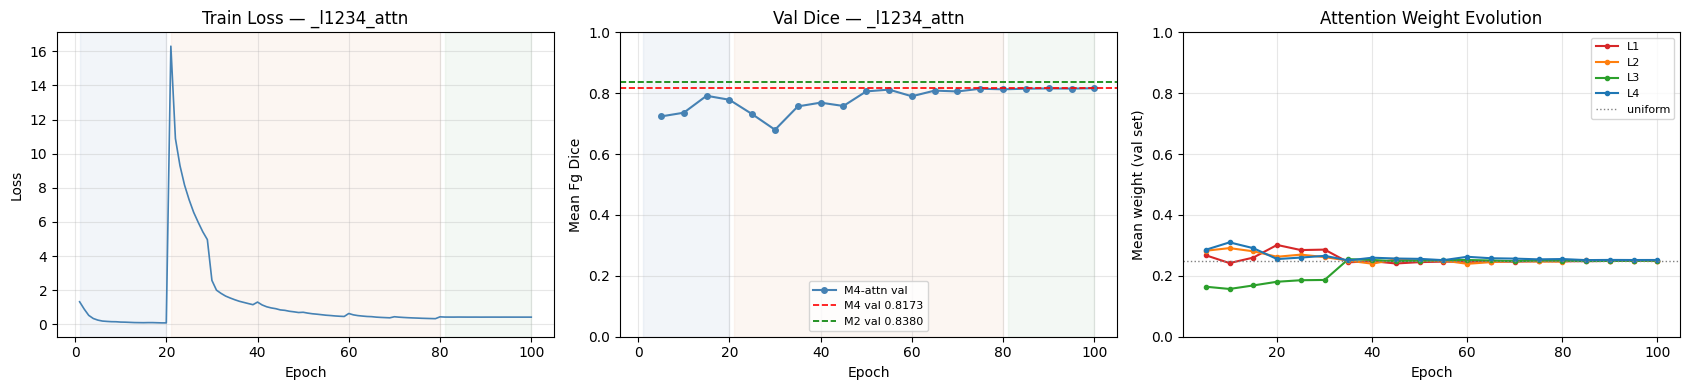

Best val Dice: 0.8164


In [6]:
import pandas as pd

log  = pd.read_csv(LOG_PATH)
val  = log.dropna(subset=['val_mean_fg_dice'])
attn = pd.read_csv(ATTN_LOG)

M4_BEST  = 0.8407   # M4 3D Dice
M2_BEST  = 0.8722   # M2 3D Dice (ceiling)
V1_VAL   = 0.8173   # M4 best val Dice
PHASE_COLORS = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}
LEVEL_COLORS = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
max_ep = log['epoch'].max()
for ax in axes[:2]:
    for ph, color in PHASE_COLORS.items():
        mask = log['phase'] == ph
        if mask.any():
            ep = log.loc[mask, 'epoch']
            ax.axvspan(ep.min(), ep.max(), alpha=0.07, color=color)

# Left: train loss
axes[0].plot(log['epoch'], log['train_loss'], lw=1.2, color='steelblue')
axes[0].set(title=f'Train Loss — {SUFFIX}', xlabel='Epoch', ylabel='Loss')
axes[0].grid(alpha=0.3)

# Middle: val Dice vs M4 and M2 baselines
axes[1].plot(val['epoch'], val['val_mean_fg_dice'], 'o-', ms=4, lw=1.5,
             color='steelblue', label='M4-attn val')
axes[1].axhline(V1_VAL,  color='red',   ls='--', lw=1.2, label=f'M4 val {V1_VAL:.4f}')
axes[1].axhline(0.8380,  color='green', ls='--', lw=1.2, label=f'M2 val 0.8380')
axes[1].set(title=f'Val Dice — {SUFFIX}', xlabel='Epoch', ylabel='Mean Fg Dice', ylim=(0, 1.0))
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

# Right: attention weight evolution
ax = axes[2]
for i, l in enumerate(PROTO_LEVELS):
    col = f'w_L{l}'
    if col in attn.columns:
        ax.plot(attn['epoch'], attn[col], 'o-', ms=3, lw=1.5,
                color=LEVEL_COLORS[i], label=f'L{l}')
ax.axhline(1 / len(PROTO_LEVELS), color='gray', ls=':', lw=1, label='uniform')
ax.set(title='Attention Weight Evolution', xlabel='Epoch',
       ylabel='Mean weight (val set)', ylim=(0, 1))
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'results/v5/train_curve{SUFFIX}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val Dice: {val["val_mean_fg_dice"].max():.4f}')

## 6. Quick 3D Dice Eval

In [7]:
from src.data.mmwhs_dataset import MMWHSPatientDataset

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=ckpt['proto_levels'],
    use_level_attention=ckpt.get('use_level_attention', False),
).to(DEVICE)
eval_model.load_state_dict(ckpt['model_state_dict'])
eval_model.eval()
print(f'Loaded: epoch {ckpt["epoch"]}  best_val {ckpt["best_val_dice"]:.4f}  '
      f'use_level_attention={ckpt.get("use_level_attention")}')

@torch.no_grad()
def eval_3d(model, modality):
    ds = MMWHSPatientDataset(DATA_DIR, modality, 'test')
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s['image'].to(DEVICE)
        logits_all = [model(imgs[si:si+1])[0].cpu() for si in range(imgs.shape[0])]
        results[s['patient']] = dice_per_class(torch.cat(logits_all), s['label'])
    return results

results = eval_3d(eval_model, MODALITY)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

M4_3D = 0.8407
M2_3D = 0.8722

print(f'\n3D Dice — {SUFFIX}')
print(f'{"Patient":<12} {"MeanFg":>7}  ' + '  '.join(f'{n[:4]:>5}' for n in FG_NAMES))
print('─' * 75)
all_means = []
for pid, dice in sorted(results.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = '  '.join(f'{dice.get(n, float("nan")):>5.3f}' for n in FG_NAMES)
    print(f'{pid:<12} {mfg:>7.4f}  {vals}')
overall = np.mean(all_means)
print('─' * 75)
print(f'{"Mean":<12} {overall:>7.4f}')
print(f'\nΔ vs M4 ({M4_3D:.4f}): {overall - M4_3D:+.4f}')
print(f'Δ vs M2 ({M2_3D:.4f}): {overall - M2_3D:+.4f}')
print('✅ beats M4' if overall > M4_3D else '⚠️ does not beat M4')

Loaded: epoch 100  best_val 0.8164  use_level_attention=True



3D Dice — _l1234_attn
Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7666  0.767  0.882  0.763  0.861  0.800  0.677  0.617
ct_1020       0.9300  0.888  0.951  0.933  0.909  0.927  0.974  0.928
───────────────────────────────────────────────────────────────────────────
Mean          0.8483

Δ vs M4 (0.8407): +0.0076
Δ vs M2 (0.8722): -0.0239
✅ beats M4


## 7. Attention Weight Inspection

Global mean attention weights:
  L1: 0.2500
  L2: 0.2500
  L3: 0.2503
  L4: 0.2497

Per-class mean attention weights:
Class            L1       L2       L3       L4
LV           0.2485   0.2533   0.2484   0.2498
RV           0.2498   0.2507   0.2495   0.2500
LA           0.2484   0.2539   0.2478   0.2499
RA           0.2490   0.2521   0.2491   0.2498
Myocardium   0.2492   0.2519   0.2490   0.2498
Aorta        0.2513   0.2475   0.2513   0.2498
PA           0.2524   0.2448   0.2533   0.2495


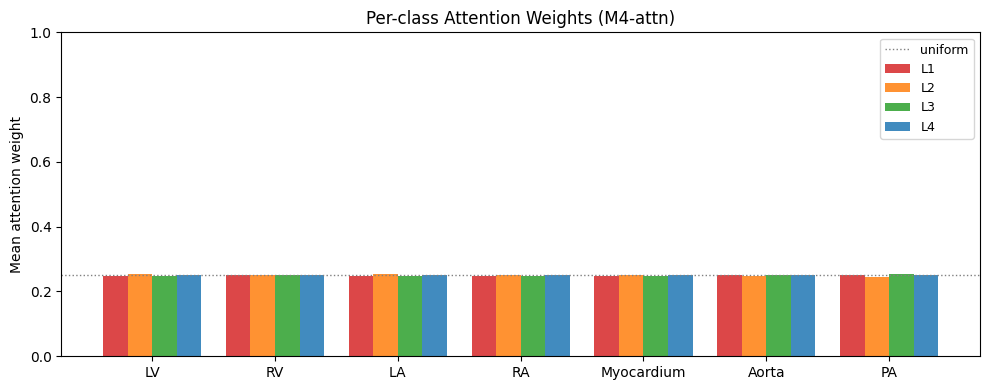

Saved attention_weights_per_class.png

RQ5 checks:
  w_L1 + w_L2 = 0.5000  (target < 0.30)
  w_L4 > w_L1 : False


In [8]:
# Final attention weights: mean per level, and per foreground class
from src.data.mmwhs_dataset import MMWHSSliceDataset

test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, 'test', augment=False, preload=True)
test_loader_noshuffle = torch.utils.data.DataLoader(test_ds, batch_size=16, shuffle=False)

eval_model.eval()
level_weights_per_class = {c: [] for c in range(1, NUM_CLASSES)}  # class → list of w
global_weights = []

with torch.no_grad():
    for batch in test_loader_noshuffle:
        imgs   = batch['image'].to(DEVICE)    # (B, 1, H, W)
        labels = batch['label']               # (B, H, W)
        w = eval_model.get_attention_weights(imgs)  # (B, n_levels)
        global_weights.append(w.cpu())

        # Per-class: average w over slices where class is present (> 1% of pixels)
        for b in range(labels.shape[0]):
            for c in range(1, NUM_CLASSES):
                frac = (labels[b] == c).float().mean().item()
                if frac > 0.01:
                    level_weights_per_class[c].append(w[b].cpu().numpy())

global_w = torch.cat(global_weights).mean(dim=0).numpy()

print('Global mean attention weights:')
for i, l in enumerate(PROTO_LEVELS):
    print(f'  L{l}: {global_w[i]:.4f}')

print('\nPer-class mean attention weights:')
print(f'{"Class":<10}', ' '.join(f'{"L"+str(l):>8}' for l in PROTO_LEVELS))
per_class_w = {}
for c in range(1, NUM_CLASSES):
    if level_weights_per_class[c]:
        w_c = np.mean(level_weights_per_class[c], axis=0)
        per_class_w[c] = w_c
        vals = ' '.join(f'{v:>8.4f}' for v in w_c)
        print(f'{LABEL_NAMES[c]:<10} {vals}')

# Bar chart: per-class attention weights
LEVEL_COLORS = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
class_names = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
x = np.arange(len(class_names))
width = 0.8 / len(PROTO_LEVELS)

fig, ax = plt.subplots(figsize=(10, 4))
for i, l in enumerate(PROTO_LEVELS):
    vals = [per_class_w.get(c, np.full(len(PROTO_LEVELS), float('nan')))[i]
            for c in range(1, NUM_CLASSES)]
    ax.bar(x + (i - len(PROTO_LEVELS)/2 + 0.5) * width, vals, width,
           label=f'L{l}', color=LEVEL_COLORS[i], alpha=0.85)

ax.axhline(1 / len(PROTO_LEVELS), color='gray', ls=':', lw=1, label='uniform')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel('Mean attention weight')
ax.set_title('Per-class Attention Weights (M4-attn)')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('results/v5/attention_weights_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved attention_weights_per_class.png')

# RQ5 quick check
print(f'\nRQ5 checks:')
print(f'  w_L1 + w_L2 = {global_w[0]+global_w[1]:.4f}  (target < 0.30)')
print(f'  w_L4 > w_L1 : {global_w[-1] > global_w[0]}')